# Modélisation supervisée — Consommation d’énergie et émissions de CO₂

Ce notebook utilise les fichiers nettoyés produits par le notebook d’analyse exploratoire.

Objectifs :

1. charger le dataset nettoyé ;
2. préparer les variables explicatives et les variables cibles ;
3. construire un pipeline de prétraitement ;
4. comparer plusieurs modèles supervisés ;
5. optimiser un modèle avec `GridSearchCV` ;
6. interpréter le modèle retenu avec une méthode de feature importance ;
7. tester l’impact de `ENERGYSTARScore` dans une analyse secondaire.

La modélisation principale est faite **sans `ENERGYSTARScore`**, car cette variable est liée à la performance énergétique du bâtiment et n’est pas strictement une caractéristique structurelle.

##  Imports

On importe les bibliothèques nécessaires pour :

- manipuler les données ;
- construire des pipelines de prétraitement ;
- entraîner plusieurs modèles de régression ;
- évaluer les performances ;
- optimiser un modèle ;
- interpréter les variables importantes.

In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

import sklearn.model_selection
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_validate

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

import sklearn.metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

## 1. Chargement du dataset nettoyé

Le fichier `Cleaned_Batiment_energie_without_score.csv` correspond au dataset principal nettoyé, sans `ENERGYSTARScore`.

Cette version est utilisée pour la modélisation principale afin de prédire la consommation d’énergie et les émissions de CO₂ à partir de caractéristiques structurelles, d’usage et de localisation.

In [92]:
# Dataset principal : sans ENERGYSTARScore
data = pd.read_csv('Cleaned_Batiment_energie_without_score.csv')

print(f"Shape du dataset principal : {data.shape}")
display(data.head())

Shape du dataset principal : (1653, 15)


,BuildingType,PrimaryPropertyType,Latitude,Longitude,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,SiteEnergyUse(kBtu),TotalGHGEmissions,Agebuilding
0,NonResidential,Hotel,47.61220,-122.33799,1.0,12,88434,0,Hotel,88434.0,No second use,0.0,7226362.5,249.98,89
1,NonResidential,Hotel,47.61317,-122.33393,1.0,11,103566,15064,Hotel,83880.0,Parking,15064.0,8387933.0,295.86,20
2,NonResidential,Hotel,47.61393,-122.33810,1.0,41,956110,196718,Hotel,756493.0,No second use,0.0,72587024.0,2089.28,47
3,NonResidential,Hotel,47.61412,-122.33664,1.0,10,61320,0,Hotel,61320.0,No second use,0.0,6794584.0,286.43,90
4,NonResidential,Hotel,47.61375,-122.34047,1.0,18,175580,62000,Hotel,123445.0,Parking,68009.0,14172606.0,505.01,36


### Vérifications rapides

Avant de modéliser, on vérifie :

- l’absence de valeurs manquantes ;
- la présence des deux variables cibles ;
- les types des variables restantes.

In [93]:
TARGETS = ['SiteEnergyUse(kBtu)', 'TotalGHGEmissions']

print("Présence des variables cibles :")
for target in TARGETS:
    print(f"- {target} : {target in data.columns}")

print("Valeurs manquantes restantes :")
missing_values = data.isna().sum()
display(missing_values[missing_values > 0])

print("Types de variables :")
display(data.dtypes.value_counts())

Présence des variables cibles :
- SiteEnergyUse(kBtu) : True
- TotalGHGEmissions : True
Valeurs manquantes restantes :


Series([], dtype: int64)

Types de variables :


float64    7
str        4
int64      4
Name: count, dtype: int64

## 2. Séparation des variables explicatives et des cibles

On sépare :

- `X` : les variables explicatives ;
- `y_energy` : la consommation d’énergie ;
- `y_ghg` : les émissions de CO₂.

Les deux cibles sont modélisées séparément, car ce sont deux problèmes de régression différents.

In [94]:
X = data.drop(columns=TARGETS)
y_energy = data['SiteEnergyUse(kBtu)']
y_ghg = data['TotalGHGEmissions']

print(f"Shape de X : {X.shape}")
print(f"Shape de y_energy : {y_energy.shape}")
print(f"Shape de y_ghg : {y_ghg.shape}")

Shape de X : (1653, 13)
Shape de y_energy : (1653,)
Shape de y_ghg : (1653,)


## 3. Séparation train / test

On garde un jeu de test de côté pour évaluer les modèles sur des données non vues pendant l’entraînement.

La même séparation est utilisée pour les deux cibles afin de comparer les résultats dans des conditions identiques.

In [95]:
X_train, X_test, y_energy_train, y_energy_test, y_ghg_train, y_ghg_test = train_test_split(
    X,
    y_energy,
    y_ghg,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_energy_train : {y_energy_train.shape}")
print(f"y_ghg_train    : {y_ghg_train.shape}")

X_train : (1322, 13)
X_test  : (331, 13)
y_energy_train : (1322,)
y_ghg_train    : (1322,)


## 4. Préparation des variables pour la modélisation

Les modèles de machine learning ne traitent pas directement toutes les variables brutes.

On distingue :

- les variables numériques : imputation éventuelle par la médiane puis standardisation ;
- les variables catégorielles : imputation par une modalité `Unknown`, puis encodage OneHot.

Le prétraitement est intégré dans un `Pipeline`, ce qui évite les fuites de données entre train et test.

In [96]:
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'string', 'category', 'bool']).columns.tolist()

print(f"Variables numériques ({len(numeric_features)}) :")
print(numeric_features)

print(f"Variables catégorielles ({len(categorical_features)}) :")
print(categorical_features)

Variables numériques (9) :
['Latitude', 'Longitude', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA', 'Agebuilding']
Variables catégorielles (4) :
['BuildingType', 'PrimaryPropertyType', 'LargestPropertyUseType', 'SecondLargestPropertyUseType']


In [97]:
# Prétraitement des variables numériques
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Prétraitement des variables catégorielles
# handle_unknown='ignore' permet de gérer une catégorie absente du train mais présente dans le test.
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', max_categories=20))
])

# Préprocesseur global
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

Le `OneHotEncoder` est utilisé pour transformer les variables catégorielles nominales, car elles ne présentent pas d'ordre naturel.

Le `StandardScaler` est utilisé pour normaliser les variables numériques, ce qui est nécessaire pour certains modèles sensibles à l'échelle des variables, comme Ridge ou SVR.

In [104]:
len(numeric_features), len(set(numeric_features))

(9, 9)

In [105]:
len(categorical_features), len(set(categorical_features))

(4, 4)

In [106]:
set(numeric_features).intersection(set(categorical_features))

set()

In [107]:
unknown_report = pd.DataFrame({
    "unknown_count": X_train[categorical_features].isna().sum(),
    "unknown_rate": X_train[categorical_features].isna().mean()
}).sort_values("unknown_rate", ascending=False)

display(unknown_report)

,unknown_count,unknown_rate
BuildingType,0,0.0
PrimaryPropertyType,0,0.0
LargestPropertyUseType,0,0.0
SecondLargestPropertyUseType,0,0.0


In [108]:
unknown_report_test = pd.DataFrame({
    "unknown_count_test": X_test[categorical_features].isna().sum(),
    "unknown_rate_test": X_test[categorical_features].isna().mean()
}).sort_values("unknown_rate_test", ascending=False)

display(unknown_report_test[unknown_report_test["unknown_count_test"] > 0])

,unknown_count_test,unknown_rate_test


In [109]:
unknown_comparison = pd.concat(
    [
        unknown_report.rename(columns={
            "unknown_count": "unknown_count_train",
            "unknown_rate": "unknown_rate_train"
        }),
        unknown_report_test
    ],
    axis=1
).sort_values("unknown_rate_train", ascending=False)

display(unknown_comparison)

,unknown_count_train,unknown_rate_train,unknown_count_test,unknown_rate_test
BuildingType,0,0.0,0,0.0
PrimaryPropertyType,0,0.0,0,0.0
LargestPropertyUseType,0,0.0,0,0.0
SecondLargestPropertyUseType,0,0.0,0,0.0


## 5 Premier modèle exemple : Ridge

Je commence par tester la chaîne complète de modélisation avec un modèle linéaire régularisé : `Ridge`.

Ce premier modèle permet de vérifier que toutes les étapes fonctionnent correctement :

- prétraitement des variables numériques et catégorielles ;
- entraînement du modèle sur le jeu d'entraînement ;
- prédiction sur le jeu de test ;
- calcul des métriques de performance.

Une fois cette démarche validée, elle sera généralisée dans une fonction afin de comparer plusieurs modèles.

In [ ]:

# Pipeline complet : prétraitement + modèle Ridge
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

ridge_pipeline

In [ ]:
# Entraînement du modèle Ridge sur le jeu d'entraînement
ridge_pipeline.fit(X_train, y_energy_train)

In [ ]:
# Prédiction sur le jeu de test
y_energy_pred_ridge = ridge_pipeline.predict(X_test)

# Affichage des premières prédictions
y_energy_pred_ridge[:10]

In [ ]:

# Prédiction sur le jeu de test
y_energy_pred_ridge = ridge_pipeline.predict(X_test)

# Calcul des métriques sur la consommation d'énergie
ridge_r2 = r2_score(y_energy_test, y_energy_pred_ridge)
ridge_mae = mean_absolute_error(y_energy_test, y_energy_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_energy_test, y_energy_pred_ridge))

print("Performance du modèle Ridge sur la consommation d'énergie")
print(f"R²   : {ridge_r2:.3f}")
print(f"MAE  : {ridge_mae:,.0f} kBtu")
print(f"RMSE : {ridge_rmse:,.0f} kBtu")

Le modèle Ridge donne une première référence linéaire.

Le R² obtenu reste faible, ce qui indique que le modèle linéaire explique seulement une partie limitée de la variabilité de la consommation d'énergie.

La différence importante entre la MAE et le RMSE suggère que le modèle fait des erreurs particulièrement fortes sur certains bâtiments atypiques ou très consommateurs.

Ce premier résultat valide la chaîne de modélisation, mais il sera nécessaire de comparer Ridge avec d'autres modèles, notamment des modèles non linéaires.

In [ ]:
scoring = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error'
}

ridge_cv_results = cross_validate(
    ridge_pipeline,
    X_train,
    y_energy_train,
    cv=5,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

ridge_cv_summary = pd.DataFrame({
    'metric': ['R²', 'MAE', 'RMSE'],
    'mean': [
        ridge_cv_results['test_r2'].mean(),
        -ridge_cv_results['test_mae'].mean(),
        -ridge_cv_results['test_rmse'].mean()
    ],
    'std': [
        ridge_cv_results['test_r2'].std(),
        ridge_cv_results['test_mae'].std(),
        ridge_cv_results['test_rmse'].std()
    ]
})

ridge_cv_summary

La validation croisée du modèle Ridge donne un R² moyen d'environ 0.43.

Ce résultat est meilleur que l'évaluation obtenue sur le jeu de test simple, mais l'écart-type reste élevé, ce qui indique que la performance du modèle varie selon les découpages de validation.

La MAE moyenne est d'environ 6,3 millions de kBtu. Le RMSE est nettement plus élevé, ce qui suggère la présence de fortes erreurs sur certains bâtiments très consommateurs.

Ridge constitue donc une première référence linéaire intéressante, mais il sera nécessaire de le comparer à d'autres modèles, notamment non linéaires.

## 6. Refactoring — Fonction d’évaluation avec validation croisée


Après avoir validé la chaîne complète de modélisation sur un premier modèle Ridge, je regroupe maintenant cette démarche dans une fonction.

Cette fonction permet d'évaluer chaque modèle avec :

- le même prétraitement ;
- les mêmes données d'entraînement ;
- la même validation croisée ;
- les mêmes métriques.

Cela garantit une comparaison équitable entre les modèles.

In [188]:


def evaluate_model_cv(model_name, model, X_train, y_train, preprocessor, cv=5):
    """
    Évalue un modèle de régression avec validation croisée.

    Paramètres
    ----------
    model_name : str
        Nom du modèle évalué.
    model : estimateur sklearn
        Modèle de régression à entraîner.
    X_train : DataFrame
        Variables explicatives du jeu d'entraînement.
    y_train : Series
        Variable cible du jeu d'entraînement.
    preprocessor : ColumnTransformer
        Préprocesseur appliqué aux variables numériques et catégorielles.
    cv : int
        Nombre de folds pour la validation croisée.

    Retour
    ------
    dict
        Dictionnaire contenant les scores moyens et écarts-types.
    """

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    scoring = {
        'r2': 'r2',
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error'
    }

    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    results = {
        'model': model_name,
        'R2_mean': cv_results['test_r2'].mean(),
        'R2_std': cv_results['test_r2'].std(),
        'MAE_mean': -cv_results['test_mae'].mean(),
        'MAE_std': cv_results['test_mae'].std(),
        'RMSE_mean': -cv_results['test_rmse'].mean(),
        'RMSE_std': cv_results['test_rmse'].std()
    }

    return results

In [186]:

ridge_result = evaluate_model_cv(
    model_name='Ridge',
    model=Ridge(),
    X_train=X_train,
    y_train=y_energy_train,
    preprocessor=preprocessor,
    cv=5
)

ridge_result

{'model': 'Ridge',
 'R2_mean': np.float64(0.42835100552466976),
 'R2_std': np.float64(0.21269754228433954),
 'MAE_mean': np.float64(6338890.258807808),
 'MAE_std': np.float64(1186615.1311814566),
 'RMSE_mean': np.float64(19052249.0721257),
 'RMSE_std': np.float64(6092266.181240497)}

In [ ]:
pd.DataFrame([ridge_result])

La fonction d'évaluation donne les mêmes résultats que le test manuel réalisé précédemment sur Ridge.

Cela confirme que la chaîne d'évaluation est correcte.  
Je peux maintenant utiliser cette fonction pour comparer plusieurs modèles avec les mêmes données, le même prétraitement, la même validation croisée et les mêmes métriques.

#### 6.1  Définition des modèles à comparer

Après avoir validé la démarche avec Ridge, je définis plusieurs modèles de régression appartenant à des familles différentes.

In [117]:
models = {
    "DummyRegressor": DummyRegressor(strategy="median"),

    "LinearRegression": LinearRegression(),

    "Ridge": Ridge(
        alpha=1.0,
        random_state=RANDOM_STATE
    ),

    "Lasso": Lasso(
        #alpha=1000,
        max_iter=50000,
        random_state=RANDOM_STATE
    ),

    "ElasticNet": ElasticNet(
        #alpha=1000,
        #l1_ratio=0.5,
        max_iter=50000,
        random_state=RANDOM_STATE
    ),

    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingRegressor(
        random_state=RANDOM_STATE
    )
}
print(f"Nombre de modèles à comparer : {len(models)}")

for name in models:
    print("-", name)

Nombre de modèles à comparer : 7
- DummyRegressor
- LinearRegression
- Ridge
- Lasso
- ElasticNet
- RandomForest
- GradientBoosting


In [115]:

# models = {
#     "DummyRegressor": DummyRegressor(strategy="median"),

#     # Modèles linéaires
#     "LinearRegression": LinearRegression(),
#     "Ridge": Ridge(random_state=RANDOM_STATE),
#     "Lasso": Lasso(random_state=RANDOM_STATE, max_iter=10000),
#     "ElasticNet": ElasticNet(random_state=RANDOM_STATE, max_iter=10000),

#     # Modèles non linéaires
#     "RandomForest": RandomForestRegressor(
#         n_estimators=200,
#         random_state=RANDOM_STATE,
#         n_jobs=-1
#     ),

#     "GradientBoosting": GradientBoostingRegressor(
#         random_state=RANDOM_STATE
#     )
# }

# print(f"Nombre de modèles à comparer : {len(models)}")

# for name in models:
#     print("-", name)

Une baseline DummyRegressor est utilisée comme point de comparaison. Elle permet de vérifier que les modèles supervisés apportent une réelle amélioration par rapport à une prédiction naïve.

La comparaison commence par plusieurs modèles linéaires simples et interprétables : LinearRegression, Ridge, Lasso et ElasticNet. Des modèles non linéaires sont ensuite testés afin de capturer d’éventuelles relations plus complexes entre les caractéristiques des bâtiments et les variables cibles.

## 7. Comparaison des modèles pour la consommation d’énergie

On évalue d’abord les modèles pour prédire `SiteEnergyUse(kBtu)`.


J'évalue maintenant chaque modèle avec la fonction définie précédemment.

Tous les modèles utilisent :

- le même jeu d'entraînement ;
- le même préprocesseur ;
- la même validation croisée à 5 folds ;
- les mêmes métriques : R², MAE et RMSE.

Les résultats sont ensuite regroupés dans un tableau afin de faciliter la comparaison.

In [118]:
# Évaluation de tous les modèles sur la consommation d'énergie

results_energy = []

for model_name, model in models.items():
    print(f"Évaluation du modèle : {model_name}")
    
    result = evaluate_model_cv(
        model_name=model_name,
        model=model,
        X_train=X_train,
        y_train=y_energy_train,
        preprocessor=preprocessor,
        cv=5
    )
    
    results_energy.append(result)

results_energy_df = pd.DataFrame(results_energy)

# Tri des modèles selon le RMSE moyen
results_energy_df = results_energy_df.sort_values(
    by='RMSE_mean',
    ascending=True
).reset_index(drop=True)

results_energy_df

Évaluation du modèle : DummyRegressor
Évaluation du modèle : LinearRegression
Évaluation du modèle : Ridge
Évaluation du modèle : Lasso


/Users/abdellah/Ma_formation_Data/projet_6/Projet_6_Batiment/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:675: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.963e+16, tolerance: 1.210e+14
  model = cd_fast.sparse_enet_coordinate_descent(
/Users/abdellah/Ma_formation_Data/projet_6/Projet_6_Batiment/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:675: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.263e+16, tolerance: 1.382e+14
  model = cd_fast.sparse_enet_coordinate_descent(
/Users/abdellah/Ma_formation_Data/projet_6/Projet_6_Batiment/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:675: ConvergenceWarning: Objective d

Évaluation du modèle : ElasticNet
Évaluation du modèle : RandomForest
Évaluation du modèle : GradientBoosting


,model,R2_mean,R2_std,MAE_mean,MAE_std,RMSE_mean,RMSE_std
0,ElasticNet,0.519279,0.190603,5.342821e+06,7.124699e+05,1.748906e+07,6.013277e+06
1,Ridge,0.428351,0.212698,6.338890e+06,1.186615e+06,1.905225e+07,6.092266e+06
2,Lasso,0.402146,0.211045,6.487458e+06,1.277914e+06,1.967955e+07,6.646860e+06
3,LinearRegression,0.401848,0.210234,6.498020e+06,1.273011e+06,1.969233e+07,6.657925e+06
4,RandomForest,0.410292,0.206314,4.767684e+06,1.280054e+06,2.214473e+07,1.399426e+07
5,GradientBoosting,0.310316,0.254303,5.150534e+06,1.826233e+06,2.356498e+07,1.436828e+07
6,DummyRegressor,-0.072849,0.045883,7.504311e+06,1.742253e+06,2.947384e+07,1.581796e+07


In [119]:
display(
        display(results_energy_df.assign(
        R2_mean=results_energy_df['R2_mean'].map('{:.3f}'.format),
        R2_std=results_energy_df['R2_std'].map('{:.3f}'.format),
        MAE_mean=results_energy_df['MAE_mean'].map('{:,.0f}'.format),
        MAE_std=results_energy_df['MAE_std'].map('{:,.0f}'.format),
        RMSE_mean=results_energy_df['RMSE_mean'].map('{:,.0f}'.format),
        RMSE_std=results_energy_df['RMSE_std'].map('{:,.0f}'.format)
    ))
)

,model,R2_mean,R2_std,MAE_mean,MAE_std,RMSE_mean,RMSE_std
0,ElasticNet,0.519,0.191,"5,342,821","712,470","17,489,057","6,013,277"
1,Ridge,0.428,0.213,"6,338,890","1,186,615","19,052,249","6,092,266"
2,Lasso,0.402,0.211,"6,487,458","1,277,914","19,679,553","6,646,860"
3,LinearRegression,0.402,0.210,"6,498,020","1,273,011","19,692,326","6,657,925"
4,RandomForest,0.410,0.206,"4,767,684","1,280,054","22,144,729","13,994,260"
5,GradientBoosting,0.310,0.254,"5,150,534","1,826,233","23,564,983","14,368,276"
6,DummyRegressor,-0.073,0.046,"7,504,311","1,742,253","29,473,843","15,817,962"


None

Sur la consommation d’énergie, ElasticNet obtient le meilleur score R² moyen en validation croisée. RandomForest obtient cependant la plus faible MAE, ce qui signifie qu’il produit en moyenne des erreurs absolues plus faibles. Comme les écarts-types restent importants, notamment pour RandomForest, une comparaison avec transformation logarithmique de la target est nécessaire avant de sélectionner le modèle final.

In [120]:
from sklearn.compose import TransformedTargetRegressor
import numpy as np

def make_log_target_pipeline(model):
    base_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    return TransformedTargetRegressor(
        regressor=base_pipeline,
        func=np.log1p,
        inverse_func=np.expm1
    )

In [123]:
def evaluate_pipeline_cv(model_name, pipeline, X_train, y_train, cv=5):
    scoring = {
        "R2": "r2",
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error"
    }

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=True
    )

    return {
        "model": model_name,
        "R2_train_mean": scores["train_R2"].mean(),
        "R2_mean": scores["test_R2"].mean(),
        "R2_std": scores["test_R2"].std(),
        "MAE_mean": -scores["test_MAE"].mean(),
        "MAE_std": scores["test_MAE"].std(),
        "RMSE_mean": -scores["test_RMSE"].mean(),
        "RMSE_std": scores["test_RMSE"].std()
    }

In [124]:
results_energy_log = []

for name, model in models.items():
    print(f"Évaluation du modèle avec target log : {name}")

    log_pipeline = make_log_target_pipeline(model)

    result = evaluate_pipeline_cv(
        model_name=name,
        pipeline=log_pipeline,
        X_train=X_train,
        y_train=y_energy_train,
        cv=5
    )

    result["target_transformation"] = "log1p"
    results_energy_log.append(result)

results_energy_log_df = pd.DataFrame(results_energy_log).sort_values(
    by="R2_mean",
    ascending=False
)

display(results_energy_log_df)

Évaluation du modèle avec target log : DummyRegressor
Évaluation du modèle avec target log : LinearRegression
Évaluation du modèle avec target log : Ridge
Évaluation du modèle avec target log : Lasso
Évaluation du modèle avec target log : ElasticNet
Évaluation du modèle avec target log : RandomForest
Évaluation du modèle avec target log : GradientBoosting


,model,R2_train_mean,R2_mean,R2_std,MAE_mean,MAE_std,RMSE_mean,RMSE_std,target_transformation
6,GradientBoosting,0.735733,4.619899e-01,2.034235e-01,4.398783e+06,1.191967e+06,2.223796e+07,1.520378e+07,log1p
5,RandomForest,0.768302,4.394302e-01,1.573644e-01,4.656510e+06,1.429285e+06,2.248842e+07,1.462456e+07,log1p
3,Lasso,-0.037274,-6.975668e-02,4.332521e-02,7.505154e+06,1.739633e+06,2.944797e+07,1.583231e+07,log1p
0,DummyRegressor,-0.038245,-7.284918e-02,4.588294e-02,7.504311e+06,1.742254e+06,2.947384e+07,1.581796e+07,log1p
4,ElasticNet,-0.006902,-9.558778e+05,1.911755e+06,1.562637e+09,3.111918e+09,2.529927e+10,5.055489e+10,log1p
1,LinearRegression,-12.172320,-4.467075e+28,8.934150e+28,3.363695e+20,6.727390e+20,5.465358e+21,1.093072e+22,log1p
2,Ridge,-13.995327,-1.295162e+29,2.590325e+29,5.727527e+20,1.145505e+21,9.306129e+21,1.861226e+22,log1p


La transformation logarithmique de la variable cible a été testée afin de réduire l’influence des bâtiments ayant des consommations très élevées.

Les résultats montrent que cette transformation améliore surtout les modèles non linéaires, notamment GradientBoosting et RandomForest, en réduisant la MAE. En revanche, les modèles linéaires deviennent instables après retour à l’échelle réelle avec la fonction exponentielle inverse. Ils ne sont donc pas retenus dans la comparaison finale avec target logarithmique.

Pour la consommation d’énergie, ElasticNet sans transformation obtient le meilleur R² moyen, tandis que GradientBoosting avec transformation logarithmique obtient la meilleure MAE. Le choix du modèle final devra donc tenir compte du compromis entre variance expliquée et erreur moyenne métier.

In [125]:
log_models = {
    "DummyRegressor": DummyRegressor(strategy="median"),

    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingRegressor(
        random_state=RANDOM_STATE
    )
}

In [126]:
results_energy_log = []

for name, model in log_models.items():
    print(f"Évaluation du modèle avec target log : {name}")

    log_pipeline = make_log_target_pipeline(model)

    result = evaluate_pipeline_cv(
        model_name=name,
        pipeline=log_pipeline,
        X_train=X_train,
        y_train=y_energy_train,
        cv=5
    )

    result["target_transformation"] = "log1p"
    results_energy_log.append(result)

results_energy_log_df = pd.DataFrame(results_energy_log).sort_values(
    by="R2_mean",
    ascending=False
)

display(results_energy_log_df)

Évaluation du modèle avec target log : DummyRegressor
Évaluation du modèle avec target log : RandomForest
Évaluation du modèle avec target log : GradientBoosting


,model,R2_train_mean,R2_mean,R2_std,MAE_mean,MAE_std,RMSE_mean,RMSE_std,target_transformation
2,GradientBoosting,0.735733,0.461990,0.203423,4.398783e+06,1.191967e+06,2.223796e+07,1.520378e+07,log1p
1,RandomForest,0.768302,0.439430,0.157364,4.656510e+06,1.429285e+06,2.248842e+07,1.462456e+07,log1p
0,DummyRegressor,-0.038245,-0.072849,0.045883,7.504311e+06,1.742254e+06,2.947384e+07,1.581796e+07,log1p


In [129]:
models = {
    "DummyRegressor": DummyRegressor(strategy="median"),
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso": Lasso(alpha=1, max_iter=50000, random_state=RANDOM_STATE),
    "ElasticNet": ElasticNet(alpha=1, l1_ratio=0.5, max_iter=50000, random_state=RANDOM_STATE),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE)
}

In [130]:
# Évaluation de tous les modèles sur la consommation d'énergie

results_energy = []

for model_name, model in models.items():
    print(f"Évaluation du modèle : {model_name}")
    
    result = evaluate_model_cv(
        model_name=model_name,
        model=model,
        X_train=X_train,
        y_train=y_energy_train,
        preprocessor=preprocessor,
        cv=5
    )
    
    results_energy.append(result)

results_energy_df = pd.DataFrame(results_energy)

# Tri des modèles selon le RMSE moyen
results_energy_df = results_energy_df.sort_values(
    by='RMSE_mean',
    ascending=True
).reset_index(drop=True)

results_energy_df

Évaluation du modèle : DummyRegressor
Évaluation du modèle : LinearRegression
Évaluation du modèle : Ridge
Évaluation du modèle : Lasso


/Users/abdellah/Ma_formation_Data/projet_6/Projet_6_Batiment/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:675: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.263e+16, tolerance: 1.382e+14
  model = cd_fast.sparse_enet_coordinate_descent(
/Users/abdellah/Ma_formation_Data/projet_6/Projet_6_Batiment/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:675: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.963e+16, tolerance: 1.210e+14
  model = cd_fast.sparse_enet_coordinate_descent(
/Users/abdellah/Ma_formation_Data/projet_6/Projet_6_Batiment/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:675: ConvergenceWarning: Objective d

Évaluation du modèle : ElasticNet
Évaluation du modèle : RandomForest
Évaluation du modèle : GradientBoosting


,model,R2_mean,R2_std,MAE_mean,MAE_std,RMSE_mean,RMSE_std
0,ElasticNet,0.519279,0.190603,5.342821e+06,7.124699e+05,1.748906e+07,6.013277e+06
1,Ridge,0.428351,0.212698,6.338890e+06,1.186615e+06,1.905225e+07,6.092266e+06
2,Lasso,0.402146,0.211045,6.487458e+06,1.277914e+06,1.967955e+07,6.646860e+06
3,LinearRegression,0.401848,0.210234,6.498020e+06,1.273011e+06,1.969233e+07,6.657925e+06
4,RandomForest,0.410292,0.206314,4.767684e+06,1.280054e+06,2.214473e+07,1.399426e+07
5,GradientBoosting,0.310316,0.254303,5.150534e+06,1.826233e+06,2.356498e+07,1.436828e+07
6,DummyRegressor,-0.072849,0.045883,7.504311e+06,1.742253e+06,2.947384e+07,1.581796e+07


## 8. Comparaison des modèles pour les émissions de CO₂

On évalue ensuite les mêmes modèles pour prédire `TotalGHGEmissions`.

In [131]:
# Évaluation des modèles pour les émissions de CO₂ (TotalGHGEmissions)
results_ghg = []

for model_name, model in models.items():
	print(f"Évaluation du modèle : {model_name}")
	result = evaluate_model_cv(
		model_name=model_name,
		model=model,
		X_train=X_train,
		y_train=y_ghg_train,
		preprocessor=preprocessor,
		cv=5
	)
	results_ghg.append(result)

results_ghg_df = pd.DataFrame(results_ghg)

results_ghg_df = results_ghg_df.sort_values(
    by='R2_mean',
    ascending=False
).reset_index(drop=True)

results_ghg_display = results_ghg_df.copy()

results_ghg_display['R2_mean'] = results_ghg_display['R2_mean'].round(3)
results_ghg_display['R2_std'] = results_ghg_display['R2_std'].round(3)

for col in ['MAE_mean', 'MAE_std', 'RMSE_mean', 'RMSE_std']:
    results_ghg_display[col] = results_ghg_display[col].round(2)

display(results_ghg_display)

Évaluation du modèle : DummyRegressor
Évaluation du modèle : LinearRegression
Évaluation du modèle : Ridge
Évaluation du modèle : Lasso
Évaluation du modèle : ElasticNet
Évaluation du modèle : RandomForest
Évaluation du modèle : GradientBoosting


,model,R2_mean,R2_std,MAE_mean,MAE_std,RMSE_mean,RMSE_std
0,ElasticNet,0.255,0.352,175.86,20.91,598.06,217.10
1,RandomForest,0.178,0.618,139.38,17.49,579.46,175.02
2,Ridge,0.170,0.544,203.91,35.71,560.68,132.22
3,Lasso,0.138,0.560,196.23,35.42,572.08,143.49
4,LinearRegression,0.123,0.596,207.38,37.06,567.79,126.92
5,DummyRegressor,-0.054,0.032,172.81,33.42,761.38,305.23
6,GradientBoosting,-0.175,1.351,136.41,9.78,598.54,197.08


Pour les émissions de CO₂ sans transformation logarithmique, ElasticNet obtient le meilleur R² moyen en validation croisée. Cependant, les écarts-types sont élevés, ce qui indique une forte variabilité des performances selon les plis. Ridge présente la RMSE moyenne la plus faible, tandis que les modèles non linéaires obtiennent les meilleures MAE. Ces résultats suggèrent que la prédiction des émissions est plus instable que celle de la consommation d’énergie, probablement en raison de valeurs extrêmes et d’une distribution très asymétrique de la target.

In [132]:
log_models = {
    "DummyRegressor": DummyRegressor(strategy="median"),

    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingRegressor(
        random_state=RANDOM_STATE
    )
}

In [134]:
results_ghg_log = []

for model_name, model in models.items():
    print(f"Évaluation du modèle avec target log : {model_name}")

    log_pipeline = make_log_target_pipeline(model)

    result = evaluate_pipeline_cv(
        model_name=model_name,
        pipeline=log_pipeline,
        X_train=X_train,
        y_train=y_ghg_train,
        cv=5
    )

    result["target_transformation"] = "log1p"
    results_ghg_log.append(result)

results_ghg_log_df = pd.DataFrame(results_ghg_log).sort_values(
    by="R2_mean",
    ascending=False
).reset_index(drop=True)

display(results_ghg_log_df)

Évaluation du modèle avec target log : DummyRegressor
Évaluation du modèle avec target log : LinearRegression
Évaluation du modèle avec target log : Ridge
Évaluation du modèle avec target log : Lasso
Évaluation du modèle avec target log : ElasticNet
Évaluation du modèle avec target log : RandomForest
Évaluation du modèle avec target log : GradientBoosting


,model,R2_train_mean,R2_mean,R2_std,MAE_mean,MAE_std,RMSE_mean,RMSE_std,target_transformation
0,GradientBoosting,0.775386,3.965149e-01,1.722029e-01,1.270278e+02,2.580555e+01,5.823790e+02,2.768800e+02,log1p
1,RandomForest,0.738613,3.799837e-01,1.547470e-01,1.310350e+02,2.943893e+01,6.005081e+02,2.899797e+02,log1p
2,Lasso,-0.031304,-5.111438e-02,2.970061e-02,1.729185e+02,3.336603e+01,7.605667e+02,3.055710e+02,log1p
3,DummyRegressor,-0.033013,-5.448948e-02,3.222333e-02,1.728089e+02,3.342048e+01,7.613762e+02,3.052290e+02,log1p
4,ElasticNet,-0.022230,-1.045724e+04,2.091439e+04,3.268725e+03,6.221951e+03,5.100398e+04,1.006705e+05,log1p
5,LinearRegression,-7.634933,-2.884746e+31,5.769492e+31,1.631411e+17,3.262823e+17,2.650730e+18,5.301459e+18,log1p
6,Ridge,-7.351467,-9.452787e+31,1.890557e+32,2.953178e+17,5.906356e+17,4.798346e+18,9.596692e+18,log1p


Pour les émissions de CO₂, la transformation logarithmique de la target améliore nettement les performances des modèles non linéaires. GradientBoosting obtient le meilleur compromis, avec le meilleur R² moyen et la plus faible MAE. Cette amélioration indique que la distribution initiale des émissions était fortement asymétrique et que le passage au logarithme réduit l’influence des bâtiments aux émissions très élevées.

In [135]:
results_ghg_df["target_transformation"] = "none"

all_ghg_results = pd.concat(
    [results_ghg_df, results_ghg_log_df],
    ignore_index=True
).sort_values(
    by="R2_mean",
    ascending=False
).reset_index(drop=True)

display(all_ghg_results)

,model,R2_mean,R2_std,MAE_mean,MAE_std,RMSE_mean,RMSE_std,target_transformation,R2_train_mean
0,GradientBoosting,3.965149e-01,1.722029e-01,1.270278e+02,2.580555e+01,5.823790e+02,2.768800e+02,log1p,0.775386
1,RandomForest,3.799837e-01,1.547470e-01,1.310350e+02,2.943893e+01,6.005081e+02,2.899797e+02,log1p,0.738613
2,ElasticNet,2.553499e-01,3.523625e-01,1.758645e+02,2.090571e+01,5.980563e+02,2.170980e+02,none,NaN
3,RandomForest,1.780173e-01,6.183491e-01,1.393823e+02,1.748805e+01,5.794635e+02,1.750235e+02,none,NaN
4,Ridge,1.701775e-01,5.435262e-01,2.039098e+02,3.570938e+01,5.606844e+02,1.322233e+02,none,NaN
5,Lasso,1.383604e-01,5.597924e-01,1.962320e+02,3.542397e+01,5.720824e+02,1.434851e+02,none,NaN
6,LinearRegression,1.227776e-01,5.957324e-01,2.073790e+02,3.706091e+01,5.677892e+02,1.269234e+02,none,NaN
7,Lasso,-5.111438e-02,2.970061e-02,1.729185e+02,3.336603e+01,7.605667e+02,3.055710e+02,log1p,-0.031304
8,DummyRegressor,-5.448933e-02,3.222314e-02,1.728089e+02,3.342048e+01,7.613762e+02,3.052290e+02,none,NaN
9,DummyRegressor,-5.448948e-02,3.222333e-02,1.728089e+02,3.342048e+01,7.613762e+02,3.052290e+02,log1p,-0.033013


## 9. Évaluation finale sur le jeu de test

Après la comparaison des modèles en validation croisée, les modèles retenus sont entraînés sur l’ensemble du jeu d’entraînement, puis évalués une seule fois sur le jeu de test.

Pour la consommation d’énergie, le modèle ElasticNet sans transformation logarithmique est retenu, car il obtient le meilleur compromis en validation croisée, notamment sur le R² moyen et la RMSE moyenne.

Pour les émissions de CO₂, le modèle GradientBoosting avec transformation logarithmique de la target est retenu. Cette transformation améliore nettement les performances pour cette variable cible, ce qui confirme que les émissions présentent une distribution fortement asymétrique.

L’évaluation sur le jeu de test permet d’estimer la capacité des modèles à généraliser sur des bâtiments non vus pendant l’entraînement.

In [136]:
def regression_metrics(y_true, y_pred):
    return {
        "R2_test": r2_score(y_true, y_pred),
        "MAE_test": mean_absolute_error(y_true, y_pred),
        "RMSE_test": root_mean_squared_error(y_true, y_pred)
    }

In [140]:
# Énergie : ElasticNet sans transformation logarithmique
final_energy_elasticnet = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", ElasticNet(
        alpha=1.0,
        l1_ratio=0.5,
        max_iter=50000,
        random_state=RANDOM_STATE
    ))
])

# Énergie : GradientBoosting avec transformation logarithmique de la target
energy_gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ))
])

final_energy_gradientboosting_log = TransformedTargetRegressor(
    regressor=energy_gb_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

# CO2 : GradientBoosting avec transformation logarithmique de la target
ghg_gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ))
])

final_ghg_gradientboosting_log = TransformedTargetRegressor(
    regressor=ghg_gb_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

In [141]:
# Entraînement
final_energy_elasticnet.fit(X_train, y_energy_train)
final_energy_gradientboosting_log.fit(X_train, y_energy_train)
final_ghg_gradientboosting_log.fit(X_train, y_ghg_train)

# Prédictions test
pred_energy_elasticnet = final_energy_elasticnet.predict(X_test)
pred_energy_gb_log = final_energy_gradientboosting_log.predict(X_test)
pred_ghg_gb_log = final_ghg_gradientboosting_log.predict(X_test)

In [142]:
test_results = pd.DataFrame([
    {
        "target": "SiteEnergyUse(kBtu)",
        "model": "ElasticNet",
        "target_transformation": "none",
        **regression_metrics(y_energy_test, pred_energy_elasticnet)
    },
    {
        "target": "SiteEnergyUse(kBtu)",
        "model": "GradientBoosting",
        "target_transformation": "log1p",
        **regression_metrics(y_energy_test, pred_energy_gb_log)
    },
    {
        "target": "TotalGHGEmissions",
        "model": "GradientBoosting",
        "target_transformation": "log1p",
        **regression_metrics(y_ghg_test, pred_ghg_gb_log)
    }
])

display(test_results)

,target,model,target_transformation,R2_test,MAE_test,RMSE_test
0,SiteEnergyUse(kBtu),ElasticNet,none,0.173642,5.330329e+06,1.534150e+07
1,SiteEnergyUse(kBtu),GradientBoosting,log1p,0.665069,3.500933e+06,9.767012e+06
2,TotalGHGEmissions,GradientBoosting,log1p,0.713933,9.208355e+01,2.623681e+02


Les résultats sur le jeu de test confirment l’intérêt de la transformation logarithmique de la variable cible. Pour la consommation d’énergie, GradientBoosting avec transformation log1p améliore nettement les performances par rapport à ElasticNet sans transformation : le R² augmente, tandis que la MAE et la RMSE diminuent.

Pour les émissions de CO₂, GradientBoosting avec transformation log1p obtient également de bonnes performances, avec un R² supérieur à 0.70 sur le jeu de test.

Le modèle GradientBoosting avec transformation logarithmique de la target est donc retenu pour la suite du projet, à la fois pour la consommation d’énergie et pour les émissions de CO₂.

## 10. Optimisation du modèle retenu

Après comparaison des modèles, `GradientBoostingRegressor` avec transformation logarithmique de la target est retenu pour les deux variables cibles.

Une optimisation des hyperparamètres est réalisée avec `GridSearchCV`. La recherche est volontairement limitée à une petite grille afin de garder un temps de calcul raisonnable et de vérifier que la démarche fonctionne correctement.

L’optimisation est réalisée en validation croisée avec le R² comme métrique principale.

### 10.1 Fonction pour créer le modèle optimisable

In [143]:
def make_gb_log_model():
    """
    Crée un modèle GradientBoosting avec :
    - prétraitement des features ;
    - transformation logarithmique de la target.
    """

    gb_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            random_state=RANDOM_STATE
        ))
    ])

    gb_log_model = TransformedTargetRegressor(
        regressor=gb_pipeline,
        func=np.log1p,
        inverse_func=np.expm1
    )

    return gb_log_model

In [144]:
param_grid_gb = {
    "regressor__model__n_estimators": [100, 200],
    "regressor__model__learning_rate": [0.05, 0.1],
    "regressor__model__max_depth": [2, 3],
    "regressor__model__min_samples_leaf": [1, 5]
}

### 10.2 GridSearchCV pour la consommation d’énergie

In [147]:
gb_log_energy = make_gb_log_model()

grid_energy = GridSearchCV(
    estimator=gb_log_energy,
    param_grid=param_grid_gb,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_energy.fit(X_train, y_energy_train)

print("Meilleurs paramètres énergie :")
print(grid_energy.best_params_)

print("Meilleur R2 CV énergie :")
print(grid_energy.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Meilleurs paramètres énergie :
{'regressor__model__learning_rate': 0.1, 'regressor__model__max_depth': 3, 'regressor__model__min_samples_leaf': 5, 'regressor__model__n_estimators': 200}
Meilleur R2 CV énergie :
0.5379752444558227


In [148]:
best_energy_model = grid_energy.best_estimator_

pred_energy_optimized = best_energy_model.predict(X_test)

energy_optimized_results = pd.DataFrame([
    {
        "target": "SiteEnergyUse(kBtu)",
        "model": "GradientBoosting_optimized",
        "target_transformation": "log1p",
        **regression_metrics(y_energy_test, pred_energy_optimized)
    }
])

display(energy_optimized_results)

,target,model,target_transformation,R2_test,MAE_test,RMSE_test
0,SiteEnergyUse(kBtu),GradientBoosting_optimized,log1p,-0.49161,4.519534e+06,2.061159e+07


L’optimisation par GridSearchCV améliore le score moyen en validation croisée pour la consommation d’énergie. Cependant, l’évaluation sur le jeu de test montre une forte dégradation des performances : le R² devient négatif et la RMSE augmente nettement.

Cette différence indique que la combinaison d’hyperparamètres sélectionnée par GridSearchCV ne généralise pas correctement sur les bâtiments du jeu de test. Le modèle optimisé n’est donc pas retenu pour la consommation d’énergie. Le modèle GradientBoosting avec transformation logarithmique de la target et paramètres par défaut est conservé, car il présente de meilleures performances sur le jeu de test.

In [149]:
energy_grid_comparison = pd.concat(
    [
        test_results[
            (test_results["target"] == "SiteEnergyUse(kBtu)") &
            (test_results["model"] == "GradientBoosting")
        ].assign(version="before_gridsearch"),
        
        energy_optimized_results.assign(version="after_gridsearch")
    ],
    ignore_index=True
)

display(energy_grid_comparison)

,target,model,target_transformation,R2_test,MAE_test,RMSE_test,version
0,SiteEnergyUse(kBtu),GradientBoosting,log1p,0.665069,3.500933e+06,9.767012e+06,before_gridsearch
1,SiteEnergyUse(kBtu),GradientBoosting_optimized,log1p,-0.491610,4.519534e+06,2.061159e+07,after_gridsearch


In [151]:
comparison_pred_energy = pd.DataFrame({
    "y_true": y_energy_test,
    "pred_before_gridsearch": pred_energy_gb_log,
    "pred_after_gridsearch": pred_energy_optimized
})

comparison_pred_energy["abs_error_before"] = (
    comparison_pred_energy["y_true"] - comparison_pred_energy["pred_before_gridsearch"]
).abs()

comparison_pred_energy["abs_error_after"] = (
    comparison_pred_energy["y_true"] - comparison_pred_energy["pred_after_gridsearch"]
).abs()

comparison_pred_energy["error_gap_after_minus_before"] = (
    comparison_pred_energy["abs_error_after"] - comparison_pred_energy["abs_error_before"]
)

display(
    comparison_pred_energy.sort_values(
        by="error_gap_after_minus_before",
        ascending=False
    ).head(20)
)

,y_true,pred_before_gridsearch,pred_after_gridsearch,abs_error_before,abs_error_after,error_gap_after_minus_before
1576,1.847034e+07,1.514808e+08,3.259596e+08,1.330105e+08,3.074892e+08,1.744788e+08
123,2.538325e+08,2.625679e+08,4.331664e+08,8.735413e+06,1.793340e+08,1.705986e+08
1641,9.366165e+05,1.946428e+06,8.451460e+06,1.009812e+06,7.514844e+06,6.505032e+06
297,0.000000e+00,4.992659e+07,5.582815e+07,4.992659e+07,5.582815e+07,5.901560e+06
1559,1.520676e+07,1.267593e+07,2.338306e+07,2.530835e+06,8.176301e+06,5.645466e+06
843,5.155090e+06,5.304586e+06,1.062159e+07,1.494959e+05,5.466498e+06,5.317002e+06
1156,2.102229e+07,2.969374e+07,3.486389e+07,8.671451e+06,1.384160e+07,5.170154e+06
582,1.077565e+07,1.805164e+07,2.250002e+07,7.275996e+06,1.172437e+07,4.448375e+06
408,7.290824e+06,1.386822e+07,1.797089e+07,6.577393e+06,1.068007e+07,4.102672e+06
1583,5.776441e+07,4.532920e+07,4.142751e+07,1.243521e+07,1.633690e+07,3.901692e+06


L’analyse des erreurs avant et après optimisation montre que le modèle optimisé produit quelques prédictions très éloignées des valeurs réelles. Ces erreurs concernent notamment des bâtiments atypiques ou à forte consommation.

Même si GridSearchCV améliore le score moyen en validation croisée, le modèle optimisé dégrade fortement les performances sur le jeu de test. La RMSE augmente nettement et le R² devient négatif, ce qui indique une mauvaise généralisation.

Le modèle optimisé n’est donc pas retenu pour la consommation d’énergie. Le modèle GradientBoosting avec transformation logarithmique de la target et paramètres par défaut est conservé, car il offre de meilleures performances sur les données non vues.

In [152]:
gb_log_ghg = make_gb_log_model()

grid_ghg = GridSearchCV(
    estimator=gb_log_ghg,
    param_grid=param_grid_gb,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_ghg.fit(X_train, y_ghg_train)

print("Meilleurs paramètres CO2 :")
print(grid_ghg.best_params_)

print("Meilleur R2 CV CO2 :")
print(grid_ghg.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Meilleurs paramètres CO2 :
{'regressor__model__learning_rate': 0.1, 'regressor__model__max_depth': 3, 'regressor__model__min_samples_leaf': 5, 'regressor__model__n_estimators': 200}
Meilleur R2 CV CO2 :
0.5073809600961559


In [153]:
best_ghg_model = grid_ghg.best_estimator_

pred_ghg_optimized = best_ghg_model.predict(X_test)

ghg_optimized_results = pd.DataFrame([
    {
        "target": "TotalGHGEmissions",
        "model": "GradientBoosting_optimized",
        "target_transformation": "log1p",
        **regression_metrics(y_ghg_test, pred_ghg_optimized)
    }
])

display(ghg_optimized_results)

,target,model,target_transformation,R2_test,MAE_test,RMSE_test
0,TotalGHGEmissions,GradientBoosting_optimized,log1p,0.587524,99.294537,315.047933


In [154]:
gb_log_ghg = make_gb_log_model()

grid_ghg = GridSearchCV(
    estimator=gb_log_ghg,
    param_grid=param_grid_gb,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_ghg.fit(X_train, y_ghg_train)

print("Meilleurs paramètres CO2 :")
print(grid_ghg.best_params_)

print("Meilleur R2 CV CO2 :")
print(grid_ghg.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Meilleurs paramètres CO2 :
{'regressor__model__learning_rate': 0.1, 'regressor__model__max_depth': 3, 'regressor__model__min_samples_leaf': 5, 'regressor__model__n_estimators': 200}
Meilleur R2 CV CO2 :
0.5073809600961559


In [156]:
ghg_grid_comparison = pd.concat(
    [
        test_results[
            (test_results["target"] == "TotalGHGEmissions") &
            (test_results["model"] == "GradientBoosting")
        ].assign(version="before_gridsearch"),

        ghg_optimized_results.assign(version="after_gridsearch")
    ],
    ignore_index=True
)

display(ghg_grid_comparison)

,target,model,target_transformation,R2_test,MAE_test,RMSE_test,version
0,TotalGHGEmissions,GradientBoosting,log1p,0.713933,92.083553,262.368146,before_gridsearch
1,TotalGHGEmissions,GradientBoosting_optimized,log1p,0.587524,99.294537,315.047933,after_gridsearch


### Conclusion de l’optimisation

L’optimisation par GridSearchCV a été testée pour les deux variables cibles avec le modèle GradientBoostingRegressor associé à une transformation logarithmique de la target.

Pour la consommation d’énergie comme pour les émissions de CO₂, les modèles optimisés obtiennent de moins bonnes performances sur le jeu de test que les modèles non optimisés. Le R² diminue, tandis que la MAE et la RMSE augmentent.

Ces résultats montrent que les meilleurs hyperparamètres trouvés en validation croisée ne généralisent pas mieux sur le jeu de test. Les modèles GradientBoostingRegressor avec paramètres par défaut sont donc conservés pour la suite, car ils présentent les meilleures performances sur les données non vues.

## 11. Interprétation du modèle retenu : feature importance

Après comparaison et évaluation finale, le modèle retenu pour les deux variables cibles est GradientBoostingRegressor avec transformation logarithmique de la target.

Pour interpréter ce modèle, on utilise l’importance globale des variables. Cette méthode permet d’identifier les variables qui contribuent le plus aux prédictions du modèle.

L’interprétation est réalisée séparément pour :
- la consommation d’énergie ;
- les émissions de CO₂.

### Réentraîner les deux modèles finaux

In [158]:
# Modèle final énergie
final_energy_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))
])

final_energy_model = TransformedTargetRegressor(
    regressor=final_energy_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

# Modèle final émissions CO2
final_ghg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))
])

final_ghg_model = TransformedTargetRegressor(
    regressor=final_ghg_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

# Entraînement sur le train
final_energy_model.fit(X_train, y_energy_train)
final_ghg_model.fit(X_train, y_ghg_train)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...m_state=42))])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed ou

### Récupérer les noms des variables après preprocessing

In [159]:
def get_feature_names_from_preprocessor(preprocessor):
    """
    Récupère les noms des variables après transformation par le ColumnTransformer.
    Compatible avec les variables numériques et catégorielles encodées.
    """
    feature_names = []

    for name, transformer, columns in preprocessor.transformers_:
        if name == "remainder":
            continue

        if hasattr(transformer, "get_feature_names_out"):
            names = transformer.get_feature_names_out(columns)
        else:
            names = columns

        feature_names.extend(names)

    return feature_names

In [160]:
# Le préprocesseur entraîné est dans le pipeline interne du TransformedTargetRegressor
energy_preprocessor_fitted = final_energy_model.regressor_.named_steps["preprocessor"]
ghg_preprocessor_fitted = final_ghg_model.regressor_.named_steps["preprocessor"]

energy_feature_names = get_feature_names_from_preprocessor(energy_preprocessor_fitted)
ghg_feature_names = get_feature_names_from_preprocessor(ghg_preprocessor_fitted)

### Extraire les importances

In [161]:
energy_gb_model = final_energy_model.regressor_.named_steps["model"]
ghg_gb_model = final_ghg_model.regressor_.named_steps["model"]

energy_importances = pd.DataFrame({
    "feature": energy_feature_names,
    "importance": energy_gb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

ghg_importances = pd.DataFrame({
    "feature": ghg_feature_names,
    "importance": ghg_gb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

In [162]:
display(energy_importances.head(20))
display(ghg_importances.head(20))

,feature,importance
4,PropertyGFATotal,0.499813
1,Longitude,0.117628
6,LargestPropertyUseTypeGFA,0.107622
0,Latitude,0.075363
13,BuildingType_SPS-District K-12,0.075332
29,PrimaryPropertyType_Supermarket/Grocery Store,0.018678
39,LargestPropertyUseType_Non-Refrigerated Warehouse,0.016389
8,Agebuilding,0.013836
53,LargestPropertyUseType_infrequent_sklearn,0.011855
48,LargestPropertyUseType_Self-Storage Facility,0.010137


,feature,importance
4,PropertyGFATotal,0.483442
6,LargestPropertyUseTypeGFA,0.132988
31,PrimaryPropertyType_Warehouse,0.037909
8,Agebuilding,0.029262
1,Longitude,0.029001
0,Latitude,0.024825
29,PrimaryPropertyType_Supermarket/Grocery Store,0.024298
18,PrimaryPropertyType_Large Office,0.019522
53,LargestPropertyUseType_infrequent_sklearn,0.016543
22,PrimaryPropertyType_Other,0.015719


### Graphique des 15 variables les plus importantes

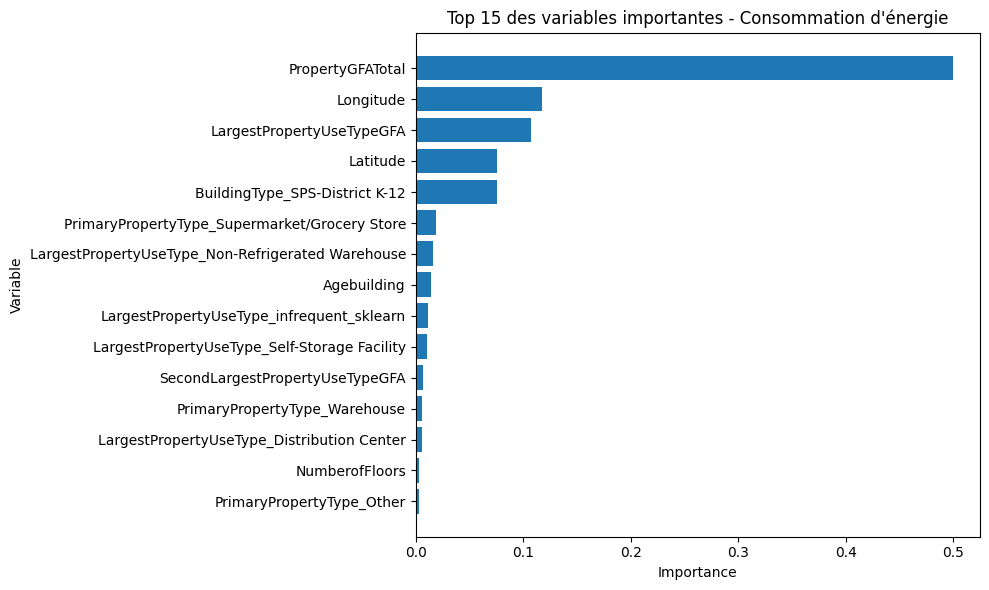

In [163]:
top_energy_importances = energy_importances.head(15).sort_values(
    by="importance",
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(top_energy_importances["feature"], top_energy_importances["importance"])
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.title("Top 15 des variables importantes - Consommation d'énergie")
plt.tight_layout()
plt.show()

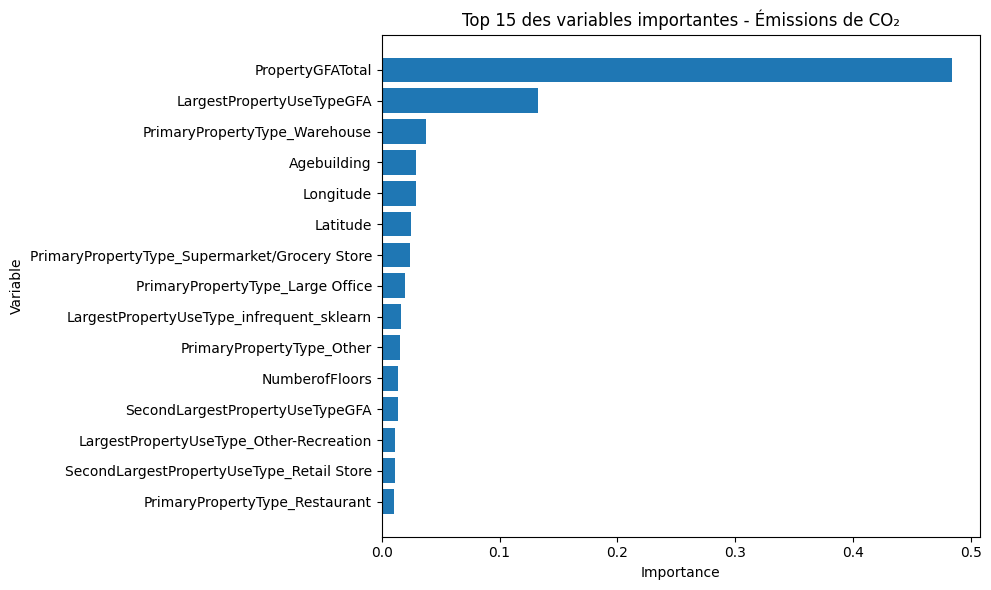

In [164]:
top_ghg_importances = ghg_importances.head(15).sort_values(
    by="importance",
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(top_ghg_importances["feature"], top_ghg_importances["importance"])
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.title("Top 15 des variables importantes - Émissions de CO₂")
plt.tight_layout()
plt.show()

### Interprétation des variables importantes

L’analyse des importances globales montre que les variables liées à la surface dominent largement les prédictions. Pour les deux targets, `PropertyGFATotal` est la variable la plus importante, avec une importance proche de 0.50. Cela indique que la surface totale du bâtiment est le principal facteur utilisé par le modèle pour prédire la consommation d’énergie et les émissions de CO₂.

La variable `LargestPropertyUseTypeGFA` arrive également parmi les plus importantes. Elle précise la surface associée à l’usage principal du bâtiment, ce qui confirme que la taille du bâtiment et la répartition de ses usages jouent un rôle central.

Pour la consommation d’énergie, les variables de localisation (`Latitude`, `Longitude`) et certains types de bâtiments, comme les établissements scolaires ou les supermarchés, apparaissent parmi les facteurs les plus influents. Cela peut refléter des différences de zones, d’activités ou de profils d’usage.

Pour les émissions de CO₂, les variables d’usage sont particulièrement présentes : entrepôts, supermarchés, grands bureaux, restaurants ou hôtels. L’âge du bâtiment apparaît aussi parmi les variables importantes, ce qui peut être lié à des différences d’efficacité énergétique ou de caractéristiques structurelles.

Ces importances doivent être interprétées avec prudence : elles indiquent quelles variables sont les plus utilisées par le modèle pour améliorer les prédictions, mais elles ne donnent pas directement le sens de l’effet. Une variable importante peut augmenter ou diminuer la prédiction selon sa valeur et ses interactions avec les autres variables.


## 13. Impact de la variable ENERGYSTARScore

La variable `ENERGYSTARScore` donne une information synthétique sur la performance énergétique d’un bâtiment. Elle peut donc potentiellement améliorer les prédictions de consommation d’énergie et d’émissions de CO₂.

Cependant, cette variable n’est pas toujours disponible pour tous les bâtiments. Une comparaison est donc réalisée entre deux versions du dataset :

- un dataset sans `ENERGYSTARScore` ;
- un dataset avec `ENERGYSTARScore`, en conservant les valeurs manquantes traitées par imputation dans le pipeline.

Le même modèle final est utilisé dans les deux cas : `GradientBoostingRegressor` avec transformation logarithmique de la target. Cela permet de mesurer uniquement l’impact de l’ajout de `ENERGYSTARScore`.

In [165]:
"ENERGYSTARScore" in X_train.columns

False

In [167]:
data_score = pd.read_csv('Cleaned_Batiment_energie_with_score.csv')
print("Shape without score :", data_score .shape)
print("Shape with score :", data.shape)

print(
    "Taux de NaN ENERGYSTARScore :",
    data_score["ENERGYSTARScore"].isna().mean()
)

Shape without score : (1653, 16)
Shape with score : (1653, 15)
Taux de NaN ENERGYSTARScore : 0.3411978221415608


#### Fonction pour préparer X/y

In [168]:
def prepare_X_y(df):
    target_energy = "SiteEnergyUse(kBtu)"
    target_ghg = "TotalGHGEmissions"
    
    X = df.drop(columns=[target_energy, target_ghg])
    y_energy = df[target_energy]
    y_ghg = df[target_ghg]
    
    return X, y_energy, y_ghg

#### Fonction pour reconstruire le preprocessor

In [169]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

def make_preprocessor(X):
    numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", max_categories=20))
    ])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )
    
    return preprocessor, numeric_features, categorical_features

In [170]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline
import numpy as np

def make_final_gb_log_model(preprocessor):
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            random_state=RANDOM_STATE
        ))
    ])
    
    model = TransformedTargetRegressor(
        regressor=pipeline,
        func=np.log1p,
        inverse_func=np.expm1
    )
    
    return model

#### Fonction d’évaluation complète

In [171]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import pandas as pd

def regression_metrics(y_true, y_pred):
    return {
        "R2_test": r2_score(y_true, y_pred),
        "MAE_test": mean_absolute_error(y_true, y_pred),
        "RMSE_test": root_mean_squared_error(y_true, y_pred)
    }


def evaluate_dataset_version(df, version_name):
    X, y_energy, y_ghg = prepare_X_y(df)
    
    X_train_v, X_test_v, y_energy_train_v, y_energy_test_v, y_ghg_train_v, y_ghg_test_v = train_test_split(
        X,
        y_energy,
        y_ghg,
        test_size=0.2,
        random_state=RANDOM_STATE
    )
    
    preprocessor_v, numeric_features_v, categorical_features_v = make_preprocessor(X_train_v)
    
    energy_model = make_final_gb_log_model(preprocessor_v)
    ghg_model = make_final_gb_log_model(preprocessor_v)
    
    energy_model.fit(X_train_v, y_energy_train_v)
    ghg_model.fit(X_train_v, y_ghg_train_v)
    
    pred_energy_v = energy_model.predict(X_test_v)
    pred_ghg_v = ghg_model.predict(X_test_v)
    
    results = pd.DataFrame([
        {
            "dataset_version": version_name,
            "target": "SiteEnergyUse(kBtu)",
            "model": "GradientBoosting",
            "target_transformation": "log1p",
            **regression_metrics(y_energy_test_v, pred_energy_v)
        },
        {
            "dataset_version": version_name,
            "target": "TotalGHGEmissions",
            "model": "GradientBoosting",
            "target_transformation": "log1p",
            **regression_metrics(y_ghg_test_v, pred_ghg_v)
        }
    ])
    
    return results

In [172]:
results_without_score = evaluate_dataset_version(
    data,
    version_name="without_ENERGYSTARScore"
)

results_with_score = evaluate_dataset_version(
    data_score,
    version_name="with_ENERGYSTARScore"
)

score_comparison_results = pd.concat(
    [results_without_score, results_with_score],
    ignore_index=True
)

display(score_comparison_results)

/var/folders/5v/ky15rjln44q9l9x27dwf5jmm0000gn/T/ipykernel_7822/1921549561.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
/var/folders/5v/ky15rjln44q9l9x27dwf5jmm0000gn/T/ipykernel_7822/1921549561.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and

,dataset_version,target,model,target_transformation,R2_test,MAE_test,RMSE_test
0,without_ENERGYSTARScore,SiteEnergyUse(kBtu),GradientBoosting,log1p,0.665069,3.500933e+06,9.767012e+06
1,without_ENERGYSTARScore,TotalGHGEmissions,GradientBoosting,log1p,0.713933,9.208355e+01,2.623681e+02
2,with_ENERGYSTARScore,SiteEnergyUse(kBtu),GradientBoosting,log1p,0.675131,3.257925e+06,9.619172e+06
3,with_ENERGYSTARScore,TotalGHGEmissions,GradientBoosting,log1p,0.853665,7.806722e+01,1.876511e+02


In [173]:
score_comparison_pivot = score_comparison_results.pivot(
    index="target",
    columns="dataset_version",
    values=["R2_test", "MAE_test", "RMSE_test"]
)

display(score_comparison_pivot)

R2_test                          \
dataset_version     with_ENERGYSTARScore without_ENERGYSTARScore   
target                                                             
SiteEnergyUse(kBtu)             0.675131                0.665069   
TotalGHGEmissions               0.853665                0.713933   

                                MAE_test                          \
dataset_version     with_ENERGYSTARScore without_ENERGYSTARScore   
target                                                             
SiteEnergyUse(kBtu)         3.257925e+06            3.500933e+06   
TotalGHGEmissions           7.806722e+01            9.208355e+01   

                               RMSE_test                          
dataset_version     with_ENERGYSTARScore without_ENERGYSTARScore  
target                                                            
SiteEnergyUse(kBtu)         9.619172e+06            9.767012e+06  
TotalGHGEmissions           1.876511e+02            2.623681e+02

In [174]:
without_score = score_comparison_results[
    score_comparison_results["dataset_version"] == "without_ENERGYSTARScore"
].set_index("target")

with_score = score_comparison_results[
    score_comparison_results["dataset_version"] == "with_ENERGYSTARScore"
].set_index("target")

score_impact = pd.DataFrame({
    "R2_without_score": without_score["R2_test"],
    "R2_with_score": with_score["R2_test"],
    "R2_gain": with_score["R2_test"] - without_score["R2_test"],
    
    "MAE_without_score": without_score["MAE_test"],
    "MAE_with_score": with_score["MAE_test"],
    "MAE_gain": without_score["MAE_test"] - with_score["MAE_test"],
    
    "RMSE_without_score": without_score["RMSE_test"],
    "RMSE_with_score": with_score["RMSE_test"],
    "RMSE_gain": without_score["RMSE_test"] - with_score["RMSE_test"]
})

display(score_impact)

,R2_without_score,R2_with_score,R2_gain,MAE_without_score,MAE_with_score,MAE_gain,RMSE_without_score,RMSE_with_score,RMSE_gain
target,,,,,,,,,
SiteEnergyUse(kBtu),0.665069,0.675131,0.010063,3.500933e+06,3.257925e+06,243008.447596,9.767012e+06,9.619172e+06,147840.549860
TotalGHGEmissions,0.713933,0.853665,0.139732,9.208355e+01,7.806722e+01,14.016329,2.623681e+02,1.876511e+02,74.717031


### Impact de la variable ENERGYSTARScore

La comparaison entre les modèles avec et sans `ENERGYSTARScore` montre que cette variable améliore les performances pour les deux targets.

Pour la consommation d’énergie, le gain est modéré : le R² passe de 0.665 à 0.675, et les erreurs MAE/RMSE diminuent légèrement. Cela indique que le score apporte une information supplémentaire, mais que la consommation reste principalement expliquée par les variables structurelles comme la surface et l’usage du bâtiment.

Pour les émissions de CO₂, l’amélioration est beaucoup plus marquée. Le R² passe de 0.714 à 0.854, tandis que la MAE et la RMSE diminuent nettement. Le score semble donc contenir une information fortement liée à la performance énergétique et environnementale du bâtiment.

Cependant, `ENERGYSTARScore` contient des valeurs manquantes et n’est pas toujours disponible. Le modèle sans score reste donc le modèle principal dans une logique opérationnelle générale. Le modèle avec score peut être considéré comme une version enrichie, utilisée lorsque cette information est disponible.

## 13. Synthèse des résultats de modélisation

La démarche de modélisation a consisté à prédire deux variables cibles :

- la consommation totale d’énergie : `SiteEnergyUse(kBtu)` ;
- les émissions de CO₂ : `TotalGHGEmissions`.

Les prédictions ont été réalisées à partir des caractéristiques structurelles des bâtiments : surface, usage, localisation, âge du bâtiment et type de bâtiment.

Une baseline `DummyRegressor` a d’abord été utilisée comme référence. Plusieurs modèles supervisés ont ensuite été comparés avec une validation croisée à 5 plis : modèles linéaires, modèles régularisés et modèles non linéaires.

Les métriques utilisées sont :
- `R²`, pour mesurer la part de variance expliquée ;
- `MAE`, pour mesurer l’erreur moyenne en valeur absolue ;
- `RMSE`, pour pénaliser davantage les fortes erreurs.

Les premières comparaisons ont montré que les variables cibles étaient difficiles à prédire directement, notamment à cause de distributions très asymétriques et de la présence de bâtiments atypiques. Une transformation logarithmique des targets a donc été testée.

Le modèle retenu est `GradientBoostingRegressor` avec transformation logarithmique de la variable cible (`log1p`) pour les deux targets.

In [175]:
final_selected_results = test_results[
    (test_results["model"] == "GradientBoosting") &
    (test_results["target_transformation"] == "log1p")
].reset_index(drop=True)

display(final_selected_results)

,target,model,target_transformation,R2_test,MAE_test,RMSE_test
0,SiteEnergyUse(kBtu),GradientBoosting,log1p,0.665069,3.500933e+06,9.767012e+06
1,TotalGHGEmissions,GradientBoosting,log1p,0.713933,9.208355e+01,2.623681e+02


### Résultats du modèle principal

Sur le jeu de test, le modèle principal obtient les performances suivantes :

- pour la consommation d’énergie, le modèle explique environ 66,5 % de la variance observée, avec une erreur moyenne d’environ 3,5 millions de kBtu ;
- pour les émissions de CO₂, le modèle explique environ 71,4 % de la variance observée, avec une erreur moyenne d’environ 92 unités de CO₂.

Ces résultats montrent que le modèle est capable de produire des prédictions pertinentes à partir des caractéristiques structurelles des bâtiments. Les erreurs restent cependant plus importantes pour certains bâtiments atypiques ou très consommateurs.

### Optimisation des hyperparamètres

Une optimisation par `GridSearchCV` a été testée sur le modèle retenu. Cependant, les modèles optimisés ont obtenu de moins bonnes performances sur le jeu de test que les modèles avec paramètres par défaut.

Pour la consommation d’énergie, le modèle optimisé a fortement dégradé les performances sur le test. L’analyse des erreurs a montré que quelques prédictions très éloignées des valeurs réelles faisaient fortement augmenter la RMSE et diminuer le R².

Pour les émissions de CO₂, l’optimisation a également dégradé les résultats sur le test.

Les modèles optimisés n’ont donc pas été retenus. Le modèle `GradientBoostingRegressor` avec paramètres par défaut est conservé, car il généralise mieux sur les données non vues.

### Interprétation des variables importantes

L’analyse des importances globales montre que les prédictions reposent principalement sur trois familles de variables :

- les variables de surface, notamment `PropertyGFATotal` et `LargestPropertyUseTypeGFA` ;
- les variables d’usage du bâtiment, comme les entrepôts, supermarchés, bureaux, hôtels ou écoles ;
- les variables de localisation et d’ancienneté, comme `Latitude`, `Longitude` et `Agebuilding`.

La surface totale du bâtiment est la variable la plus importante pour les deux targets. Cela confirme une logique métier attendue : plus un bâtiment est grand, plus sa consommation d’énergie et ses émissions de CO₂ ont tendance à être élevées.

Ces importances doivent être interprétées comme des importances globales : elles indiquent quelles variables contribuent le plus aux prédictions, mais elles ne donnent pas directement le sens de l’effet.

### Impact de la variable ENERGYSTARScore

Une comparaison complémentaire a été réalisée avec et sans la variable `ENERGYSTARScore`.

L’ajout de cette variable améliore les performances pour les deux targets. Le gain est modéré pour la consommation d’énergie : le R² passe d’environ 0.665 à 0.675. En revanche, le gain est beaucoup plus marqué pour les émissions de CO₂ : le R² passe d’environ 0.714 à 0.854, avec une baisse nette de la MAE et de la RMSE.

Cependant, `ENERGYSTARScore` contient des valeurs manquantes et n’est pas toujours disponible. Le modèle sans score est donc conservé comme modèle principal, car il repose uniquement sur des caractéristiques structurelles plus facilement disponibles. Le modèle avec score peut être considéré comme une version enrichie, utilisable lorsque cette information est disponible.

### Conclusion générale

Le modèle final retenu est un `GradientBoostingRegressor` avec transformation logarithmique de la target. Il permet de prédire à la fois la consommation d’énergie et les émissions de CO₂ à partir des caractéristiques structurelles des bâtiments.

Les résultats sont meilleurs pour les émissions de CO₂ que pour la consommation d’énergie. L’ajout de `ENERGYSTARScore` améliore nettement les performances, surtout pour les émissions, mais cette variable doit être utilisée avec prudence en raison de ses valeurs manquantes.

La démarche retenue permet donc de proposer un modèle principal robuste, utilisable sans score énergétique, ainsi qu’un modèle enrichi lorsque `ENERGYSTARScore` est disponible.

## ============================================================
## Export du modèle final pour BentoML
## ============================================================

In [177]:
# Vérification des features utilisées par le modèle final

X, y_energy, y_ghg = prepare_X_y(data)

print("Nombre de features :", X.shape[1])
print("Liste des features :")
for col in X.columns:
    print("-", col)

Nombre de features : 13
Liste des features :
- BuildingType
- PrimaryPropertyType
- Latitude
- Longitude
- NumberofBuildings
- NumberofFloors
- PropertyGFATotal
- PropertyGFAParking
- LargestPropertyUseType
- LargestPropertyUseTypeGFA
- SecondLargestPropertyUseType
- SecondLargestPropertyUseTypeGFA
- Agebuilding


In [183]:
import sys
!{sys.executable} -m pip install bentoml

  Using cached bentoml-1.4.39-py3-none-any.whl.metadata (15 kB)
  Using cached a2wsgi-1.10.10-py3-none-any.whl.metadata (4.0 kB)
  Using cached aiohttp-3.14.0-cp313-cp313-macosx_10_13_x86_64.whl.metadata (8.3 kB)
  Using cached aiohttp_asgi_connector-1.1.2-py3-none-any.whl.metadata (3.4 kB)
  Using cached aiosqlite-0.22.1-py3-none-any.whl.metadata (4.3 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached cattrs-23.1.2-py3-none-any.whl.metadata (9.3 kB)
  Using cached click_option_group-0.5.9-py3-none-any.whl.metadata (5.8 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached fsspec-2026.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached httpx_ws-0.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached kantoku-0.18.3-py3-none-any.whl.metadata (2.1 kB)
  Using cached nvidia_ml_py-13.610.43-py3-none-any.

In [184]:
import bentoml
import bentoml.sklearn

print("BentoML installé :", bentoml.__version__)

BentoML installé : 1.4.39


In [185]:
# ============================================================
# Sauvegarde du modèle final pour la Mission 2 - API BentoML
# ============================================================

import bentoml
import pandas as pd

# 1. Préparation des données
X, y_energy, y_ghg = prepare_X_y(data)

# 2. Reconstruction du preprocessor
preprocessor, numeric_features, categorical_features = make_preprocessor(X)

# 3. Création du modèle final retenu
final_energy_model = make_final_gb_log_model(preprocessor)

# 4. Entraînement sur toutes les données disponibles
final_energy_model.fit(X, y_energy)

# 5. Sauvegarde des informations utiles pour l'API
feature_names = X.columns.tolist()

# 6. Sauvegarde du modèle dans BentoML
bento_model = bentoml.sklearn.save_model(
    name="building_energy_model",
    model=final_energy_model,
    custom_objects={
        "feature_names": feature_names,
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
        "target": "SiteEnergyUse(kBtu)",
        "target_transformation": "log1p",
        "model_type": "GradientBoostingRegressor"
    }
)

print("Modèle sauvegardé avec succès dans BentoML.")
print("Nom du modèle :", bento_model.tag)
print("Nombre de features sauvegardées :", len(feature_names))
print("Features :", feature_names)

/var/folders/5v/ky15rjln44q9l9x27dwf5jmm0000gn/T/ipykernel_7822/1921549561.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


Modèle sauvegardé avec succès dans BentoML.
Nom du modèle : building_energy_model:buwe3fc7d6v7ldef
Nombre de features sauvegardées : 13
Features : ['BuildingType', 'PrimaryPropertyType', 'Latitude', 'Longitude', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'LargestPropertyUseType', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA', 'Agebuilding']
